# Demo: Summary

This notebook demonstrates the new `Summary` class for measured-data summary plots.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pythermalcomfort.models import pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib.summary import Summary
from pythermalcomfort.plots.matplotlib.threshold import Threshold, ThresholdsConfig

## Create A Small Measured DataFrame

The summary prototype works from a DataFrame

In [2]:
df = pd.DataFrame(
    {
        "tdb": [20.0, 22.0, 23.5, 24.5, 26.0, 27.5, 29.0, 20.0],
        "rh": [50.0, 45.0, 50.0, 50.0, 55.0, 60.0, 60.0, 65.0],
        "tr": [20.0, 21.5, 23.5, 24.5, 26.0, 28.0, 29.5, 20.0],
        "vr": [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10],
        "met": [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
        "clo": [0.90, 0.80, 0.60, 0.50, 0.50, 0.40, 0.35, 0.80],
        "wme": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    }
)

df

,tdb,rh,tr,vr,met,clo,wme
0,20.0,50.0,20.0,0.1,1.2,0.90,0.0
1,22.0,45.0,21.5,0.1,1.2,0.80,0.0
2,23.5,50.0,23.5,0.1,1.2,0.60,0.0
3,24.5,50.0,24.5,0.1,1.2,0.50,0.0
4,26.0,55.0,26.0,0.1,1.2,0.50,0.0
5,27.5,60.0,28.0,0.1,1.2,0.40,0.0
6,29.0,60.0,29.5,0.1,1.2,0.35,0.0
7,20.0,65.0,20.0,0.1,1.2,0.80,0.0


## The user need to calcaute the pmv
The following code is used to calcaulte the pmv and added to the dataframe

In [3]:
df["pmv"] = [
    pmv_ppd_iso(
        tdb=row.tdb,
        tr=row.tr,
        vr=row.vr,
        rh=row.rh,
        met=row.met,
        clo=row.clo,
        wme=row.wme,
    ).pmv
    for row in df.itertuples(index=False)
]
df

,tdb,rh,tr,vr,met,clo,wme,pmv
0,20.0,50.0,20.0,0.1,1.2,0.90,0.0,-0.50
1,22.0,45.0,21.5,0.1,1.2,0.80,0.0,-0.28
2,23.5,50.0,23.5,0.1,1.2,0.60,0.0,-0.16
3,24.5,50.0,24.5,0.1,1.2,0.50,0.0,-0.06
4,26.0,55.0,26.0,0.1,1.2,0.50,0.0,0.42
5,27.5,60.0,28.0,0.1,1.2,0.40,0.0,0.86
6,29.0,60.0,29.5,0.1,1.2,0.35,0.0,1.31
7,20.0,65.0,20.0,0.1,1.2,0.80,0.0,-0.60


## Default Summary Example

This example uses the default labels and colors.

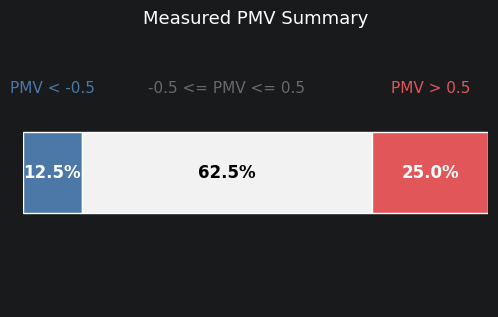

In [4]:
result = Summary.data(df).plot(
    output="pmv",
    thresholds=ThresholdsConfig(thresholds=[-0.5, 0.5]),
    title="Measured PMV Summary",
)

## Region Percentages

In [5]:
result.region_percentages

pmv_label
PMV < -0.5            12.5
-0.5 <= PMV <= 0.5    62.5
PMV > 0.5             25.0
Name: proportion, dtype: float64

## Processed DataFrame

The returned DataFrame includes both the computed output column and the output label column.

In [6]:
result.data

,tdb,rh,tr,vr,met,clo,wme,pmv,pmv_label
0,20.0,50.0,20.0,0.1,1.2,0.90,0.0,-0.50,-0.5 <= PMV <= 0.5
1,22.0,45.0,21.5,0.1,1.2,0.80,0.0,-0.28,-0.5 <= PMV <= 0.5
2,23.5,50.0,23.5,0.1,1.2,0.60,0.0,-0.16,-0.5 <= PMV <= 0.5
3,24.5,50.0,24.5,0.1,1.2,0.50,0.0,-0.06,-0.5 <= PMV <= 0.5
4,26.0,55.0,26.0,0.1,1.2,0.50,0.0,0.42,-0.5 <= PMV <= 0.5
5,27.5,60.0,28.0,0.1,1.2,0.40,0.0,0.86,PMV > 0.5
6,29.0,60.0,29.5,0.1,1.2,0.35,0.0,1.31,PMV > 0.5
7,20.0,65.0,20.0,0.1,1.2,0.80,0.0,-0.60,PMV < -0.5


## Vertical Summary Example

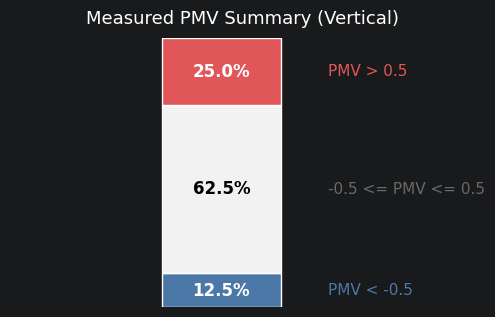

In [7]:
result = Summary.data(df).plot(
    output="pmv",
    thresholds=ThresholdsConfig(thresholds=[-0.5, 0.5]),
    vertical=True,
    title="Measured PMV Summary (Vertical)",
)

## Custom Labels, Colors, And Title

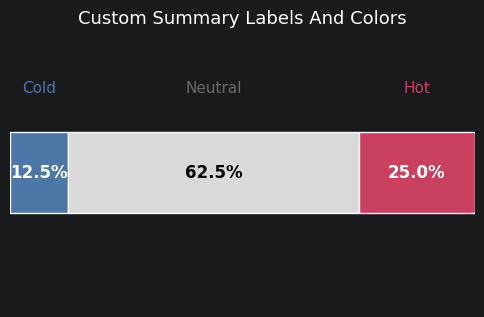

In [8]:
result = Summary.data(df).plot(
    output="pmv",
    thresholds=ThresholdsConfig(
        thresholds=[-0.5, 0.5],
        labels=["Cold", "Neutral", "Hot"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    ),
    title="Custom Summary Labels And Colors",
)

## UTCI Summary Example

The `Summary` workflow also works with UTCI. Compute the UTCI output column first, then pass the DataFrame to `Summary`.

In [9]:
df_utci = pd.DataFrame(
    {
        "tdb": [10.0, 14.0, 18.0, 24.0, 28.0, 32.0, 36.0],
        "tr": [5.0, 10.0, 18.0, 24.0, 28.0, 32.0, 36.0],
        "v": [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        "rh": [30.0, 40.0, 45.0, 50.0, 55.0, 60.0, 70.0],
    }
)

df_utci["utci"] = [
    utci(tdb=row.tdb, tr=row.tr, v=row.v, rh=row.rh).utci
    for row in df_utci.itertuples(index=False)
]

df_utci

,tdb,tr,v,rh,utci
0,10.0,5.0,0.5,30.0,8.3
1,14.0,10.0,0.5,40.0,12.6
2,18.0,18.0,0.5,45.0,17.8
3,24.0,24.0,0.5,50.0,23.8
4,28.0,28.0,0.5,55.0,28.6
5,32.0,32.0,0.5,60.0,33.9
6,36.0,36.0,0.5,70.0,42.2


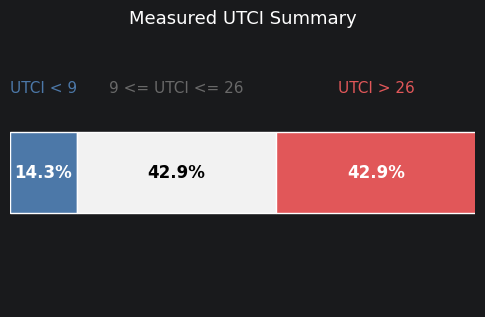

In [10]:
result_utci = Summary.data(df_utci).plot(
    output="utci",
    thresholds=ThresholdsConfig(thresholds=[9, 26]),
    title="Measured UTCI Summary",
)

In [11]:
result_utci.region_percentages

utci_label
UTCI < 9           14.3
9 <= UTCI <= 26    42.9
UTCI > 26          42.9
Name: proportion, dtype: float64

In [12]:
result_utci.data

,tdb,tr,v,rh,utci,utci_label
0,10.0,5.0,0.5,30.0,8.3,UTCI < 9
1,14.0,10.0,0.5,40.0,12.6,9 <= UTCI <= 26
2,18.0,18.0,0.5,45.0,17.8,9 <= UTCI <= 26
3,24.0,24.0,0.5,50.0,23.8,9 <= UTCI <= 26
4,28.0,28.0,0.5,55.0,28.6,UTCI > 26
5,32.0,32.0,0.5,60.0,33.9,UTCI > 26
6,36.0,36.0,0.5,70.0,42.2,UTCI > 26


## Threshold Plot + Summary Panel

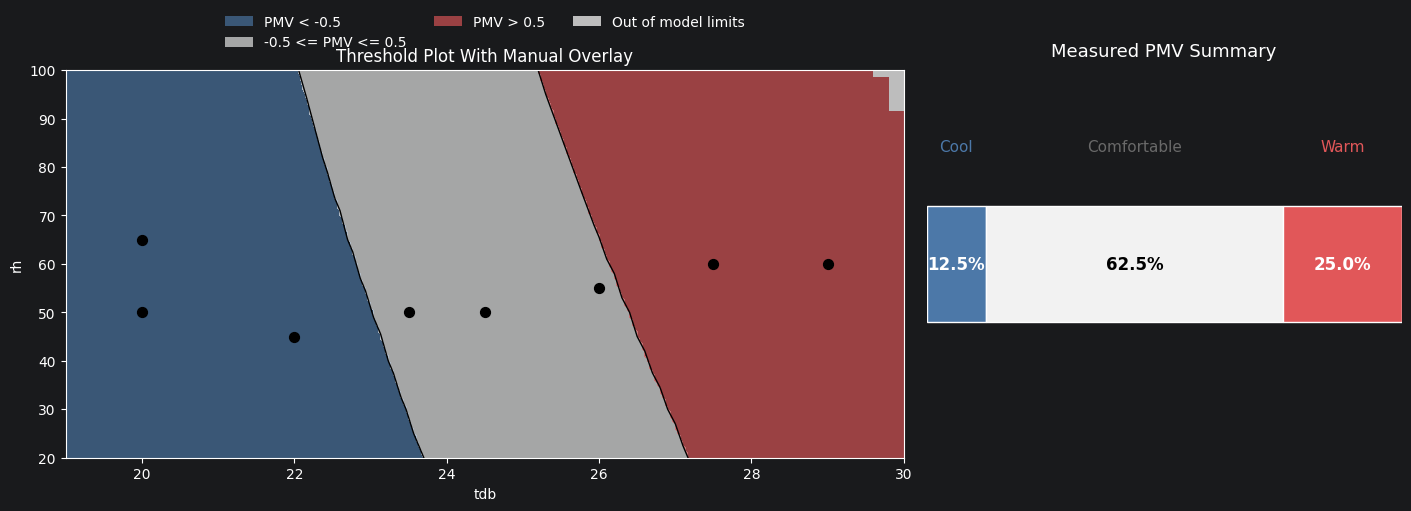

In [13]:
fig, (ax0, ax1) = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [3.0, 1.7]},
)

result = (
    Threshold(model_func=pmv_ppd_iso)
    .x(tdb=(19, 30.0))
    .y(rh=(20.0, 100.0))
    .parameters(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .plot(
        output="pmv",
        thresholds=ThresholdsConfig(thresholds=[-0.5, 0.5]),
        title="Threshold Plot With Manual Overlay",
        x_resolution=0.2,
        y_resolution=0.5,
        ax=ax0,
    )
)

result.ax.scatter(
    df["tdb"],
    df["rh"],
    color="black",
    s=50,
)


summary = Summary.data(df).plot(
    output="pmv",
    thresholds=ThresholdsConfig(
        thresholds=[-0.5, 0.5],
        labels=["Cool", "Comfortable", "Warm"],
    ),
    title="Measured PMV Summary",
    ax=ax1,
)

plt.show()